In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

pd.set_option('display.max_columns', None)



In [4]:
df = pd.read_csv('../data/raw/loan_applications.csv')

# df.head(10)
display(df.describe())
df.shape
df.info()

,age,employment_years,annual_income,credit_score,loan_amount,loan_term_months,existing_debt,num_open_accounts,num_late_payments,dti_ratio,origination_year,fed_funds_rate,interest_rate_offered
count,5030.000000,5030.000000,4725.000000,4625.000000,5030.000000,5030.000000,5030.000000,5030.000000,5030.000000,5030.000000,5030.000000,5030.000000,5030.000000
mean,37.810736,4.842843,55111.764789,351.928649,46029.483101,51.089463,20062.536873,4.018091,0.794632,0.292499,2021.995427,2.248670,4.585878
std,9.437235,4.743611,40699.705991,41.443923,36622.062338,25.071105,21909.990304,2.002948,1.228583,0.589165,0.816768,2.061794,3.183467
min,22.000000,0.000000,1993.230000,300.000000,5000.000000,12.000000,613.470000,0.000000,0.000000,0.000500,2021.000000,-0.400000,2.500000
25%,31.000000,1.400000,28629.700000,315.000000,22700.000000,36.000000,7437.802500,3.000000,0.000000,0.037125,2021.000000,0.177000,2.500000
50%,38.000000,3.400000,45524.820000,348.000000,35900.000000,48.000000,13546.255000,4.000000,0.000000,0.089550,2022.000000,1.681000,3.095000
75%,44.000000,6.700000,70522.690000,380.000000,57675.000000,60.000000,24331.072500,5.000000,1.000000,0.236425,2023.000000,4.916750,5.653250
max,70.000000,40.000000,720319.790000,542.000000,426200.000000,120.000000,300000.000000,13.000000,5.000000,4.903568,2023.000000,5.531000,28.000000


<class 'pandas.DataFrame'>
RangeIndex: 5030 entries, 0 to 5029
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   borrower_id            5030 non-null   str    
 1   age                    5030 non-null   int64  
 2   employment_type        5030 non-null   str    
 3   employment_years       5030 non-null   float64
 4   annual_income          4725 non-null   float64
 5   credit_score           4625 non-null   float64
 6   loan_amount            5030 non-null   float64
 7   loan_term_months       5030 non-null   int64  
 8   loan_purpose           5030 non-null   str    
 9   existing_debt          5030 non-null   float64
 10  num_open_accounts      5030 non-null   int64  
 11  num_late_payments      5030 non-null   int64  
 12  dti_ratio              5030 non-null   float64
 13  origination_date       5030 non-null   str    
 14  origination_year       5030 non-null   int64  
 15  origination_qua

# Handle Missing Values
- there are missing vals in annual income and credit score, later ill explore this if it has a pattern
- will decide later for impute or dropping


In [5]:
missing_vals = df.isnull().sum()
missing_percent = ((missing_vals / len(df)) * 100).round(2)



missing_df = pd.DataFrame({'Missing_Count': missing_vals, 'Percentage(%)': missing_percent})
missing_df[missing_df['Missing_Count'] > 0].sort_values('Percentage(%)', ascending=False)

,Missing_Count,Percentage(%)
credit_score,405,8.05
annual_income,305,6.06


# Duplicates
- checked for duplicates and tried looking at it if its just the name or some columns are duplicated
- turns out all the duplicated rows are same in across all the cols
- decided to drop it

In [6]:
df_copy = df.copy()

duplicates = df_copy[df_copy.duplicated(keep=False)]
# display(duplicates.sort_values(by=df_copy.columns.tolist()))

id_duplicates = df[df.duplicated(subset=['borrower_id'], keep=False)]
# display(id_duplicates.sort_values(by='borrower_id'))

df_copy = df_copy.drop_duplicates()

# Univariate Analysis
- Check for relation and distribution of numerical and categorical vals
- check for outliers

# Documentation
- drop the unrelated cols for categorical such as id and date
- check for skewness and kurtosis
- checked for the distribution of categorical cols and found typos and inconcsistent typing of data values
- fixed the categorical columns value inconsistencies

# Findings 
- from just the plots the distribution of data is leaning more on the left most part of the data meaning its either most of the loans are on the minimal side.In other words we can say that most of the data is positively skewed
- theres not much visible outliers other than the loan_term_months col which has data points outside the box plit and hist
- there are columns that has extreme measures of kurtosis and skewness such as existing debt, annual_income, loan_amount, and dti_ratio. needs more feature engineering for scaling using log transform,box-cox robust scaler or standard. 
- the distribution of categorical value counts is pretty fair and I believe there is nothing to drop. After cleaning values are considered good for the scaling

In [33]:
# df.info()
num_cols = df_copy.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = df_copy.select_dtypes(include=['str']).columns.tolist()

cat_cols.remove('borrower_id')
cat_cols.remove('origination_date')

# print(f"Numerical columns: {num_cols}")
# print(f"Categorical columns: {cat_cols}")

for col in num_cols:
    fig, ax = plt.subplots(1, 2, figsize=(15,4))

    sns.histplot(df_copy[col], kde=True, ax=ax[0], color='blue')
    ax[0].set_title(f"Distribution of {col}")
    
    sns.boxplot(x=df_copy[col], ax=ax[1], color='orange')
    ax[1].set_title(f"Boxplot of {col}")
    
    plt.tight_layout()
    plt.savefig(f'../reports/num_figures/{col}_distribution.png', dpi=200)
    plt.close()
    
    skewness = df_copy[col].skew()
    kurtosis = df_copy[col].kurtosis()
    print(f"[{col}] - Skewness: {skewness:.2f} | Kurtosis: {kurtosis:.2f}")
    if abs(skewness) > 1:
        print(f"  -> {col} is highly skewed.")
    
# outlier_cols = ['loan_term_months']

if 'loan_purpose' in cat_cols:
    df_copy['loan_purpose'] = df_copy['loan_purpose'].str.title().str.strip()
if 'employment_type' in cat_cols:
    df_copy['employment_type'] = df_copy['employment_type'].str.title().str.strip()
    df_copy['employment_type'] = df_copy['employment_type'].str.replace('_', '-').str.replace('Self Employed', 'Self-Employed')


for col in cat_cols:
    plt.figure(figsize=(10,5))
    order = df_copy[col].value_counts().index
    ax = sns.countplot(x=col, data=df_copy, order=order, palette='Set2', hue=col)
    plt.title(f"Frequency of {col}")
    plt.xticks(rotation=45)
    
    total = len(df_copy[col].dropna())
    for p in ax.patches:
        percentage = f'{100 * p.get_height() / total:.1f}%'
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax.annotate(percentage, (x, y), ha='center', va='bottom')
        
    plt.tight_layout()
    plt.savefig(f'../reports/cat_figures/{col}_frequency.png', dpi=200)
    # plt.show()
    plt.close()

[age] - Skewness: 0.26 | Kurtosis: -0.36
[employment_years] - Skewness: 1.87 | Kurtosis: 5.05
  -> employment_years is highly skewed.
[annual_income] - Skewness: 2.80 | Kurtosis: 21.99
  -> annual_income is highly skewed.
[credit_score] - Skewness: 0.61 | Kurtosis: 0.00
[loan_amount] - Skewness: 2.70 | Kurtosis: 12.62
  -> loan_amount is highly skewed.
[loan_term_months] - Skewness: 1.09 | Kurtosis: 1.18
  -> loan_term_months is highly skewed.
[existing_debt] - Skewness: 3.95 | Kurtosis: 26.98
  -> existing_debt is highly skewed.
[num_open_accounts] - Skewness: 0.47 | Kurtosis: 0.18
[num_late_payments] - Skewness: 1.64 | Kurtosis: 1.96
  -> num_late_payments is highly skewed.
[dti_ratio] - Skewness: 3.88 | Kurtosis: 17.50
  -> dti_ratio is highly skewed.
[origination_year] - Skewness: 0.01 | Kurtosis: -1.50
[fed_funds_rate] - Skewness: 0.42 | Kurtosis: -1.48
[interest_rate_offered] - Skewness: 2.64 | Kurtosis: 9.67
  -> interest_rate_offered is highly skewed.
[annual_income_log] - Skew

# Bivariate & Multivariate Analysis
- Explore relationships betweeen variables

### Bivariate Analysis: Correlation Insights

A Pearson correlation matrix was generated to identify linear relationships between numerical features.

#### Key Findings:
1. **Strong Multicollinearity:** `origination_year` and `fed_funds_rate` show a correlation of **0.98**. To prevent feature redundancy, one of these may be dropped during feature selection.
2. **Target Relationship:** The target variable `interest_rate_offered` is most strongly correlated with `dti_ratio` (**0.78**), followed by `fed_funds_rate` (**0.44**) and `origination_year` (**0.41**).
3. **Weak Predictors:** Features like `num_open_accounts` and `loan_amount` show near-zero correlation with the interest rate, suggesting they may provide less predictive power in a linear context.

#### Strategy:
- Visualize `dti_ratio` vs `interest_rate_offered` using a scatter plot to check for non-linear patterns.
- Investigate the negative relationship between `age` and `credit_score` (-0.43) to ensure data integrity.

# Num vs Num (Correlation Heatmap)

- A correlation Matrix is generated to identify linear relationshpis between num cols

## Findings
1. there is a very strong collinearity on 'origination_year' and 'fed_funds_rate' the correlation shows 98% for stratgey it would be best to drop of these 
2. moreover there is also a collinearity on 'dti_ratio' and 'interest_rate_offered' with 78% and would be best to inspect for scatter plots to check the linearity 
3. Moderate Positive Correlation age and credit_score show a correlation of 0.43, suggesting that as age increases, credit scores tend to improve moderately in this dataset.

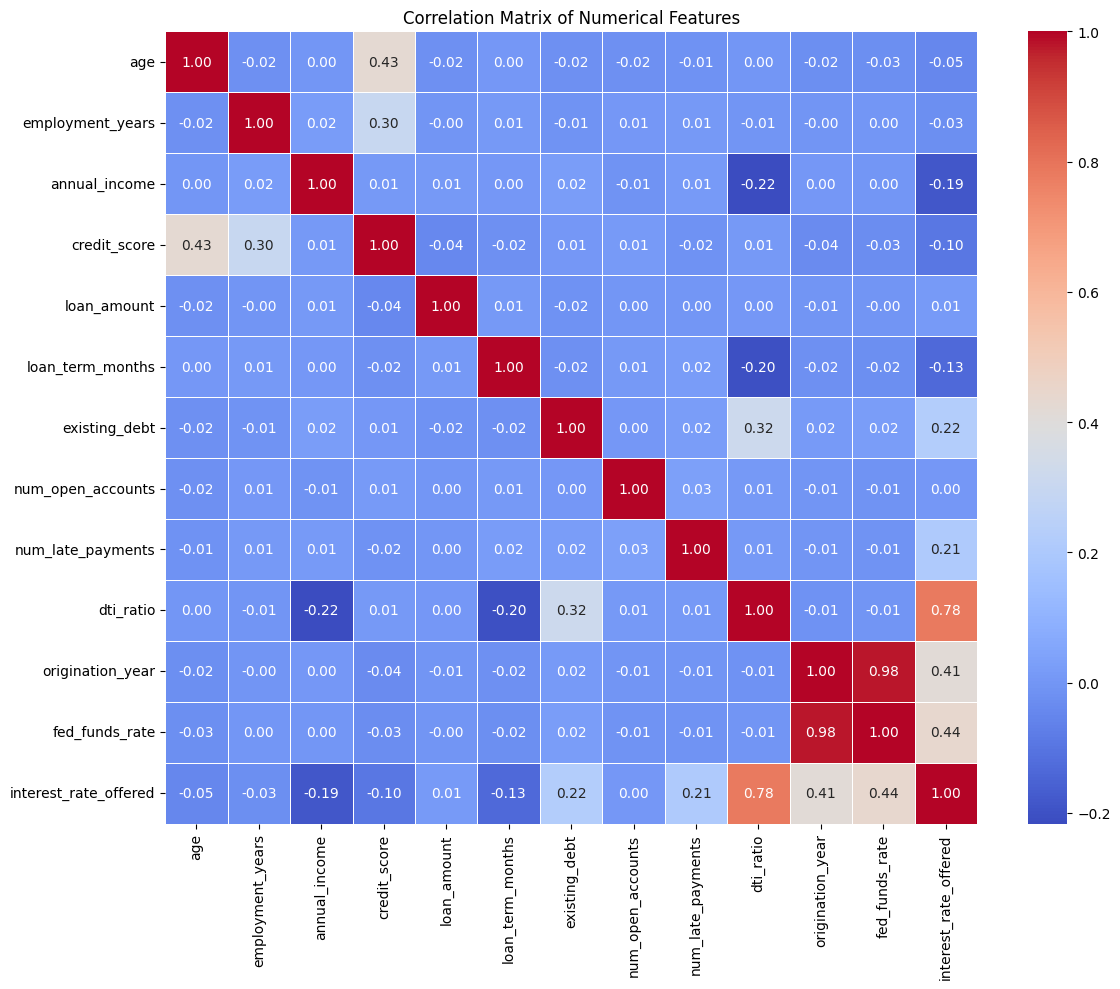

In [ ]:
corr_matrix = df_copy[num_cols].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.savefig('../reports/num_figures/corr_matrix.png', dpi=300)

# dti_ratio x interest_rate_offered
# fed_funds_rate x origination_year



### Categorical vs. Numeric
Investigating how numerical values (like the target variable `interest_rate_offered` or `loan_amount`) vary across different categories.

## Findings 

1. Employment Type x Interest Rate: the unemployed category shows significant highger median interest rate and and much larger IQR compared to other groups. **Outlier Notes**: salaried and self-employed have some outliers that might affecct the modeling
2. Loan amount by loan purpose:  the median on all groups looks consistent among all groups. **Outlier notes** there are some outliers onn auto, debt consolidation, home improvement, education and vacation.


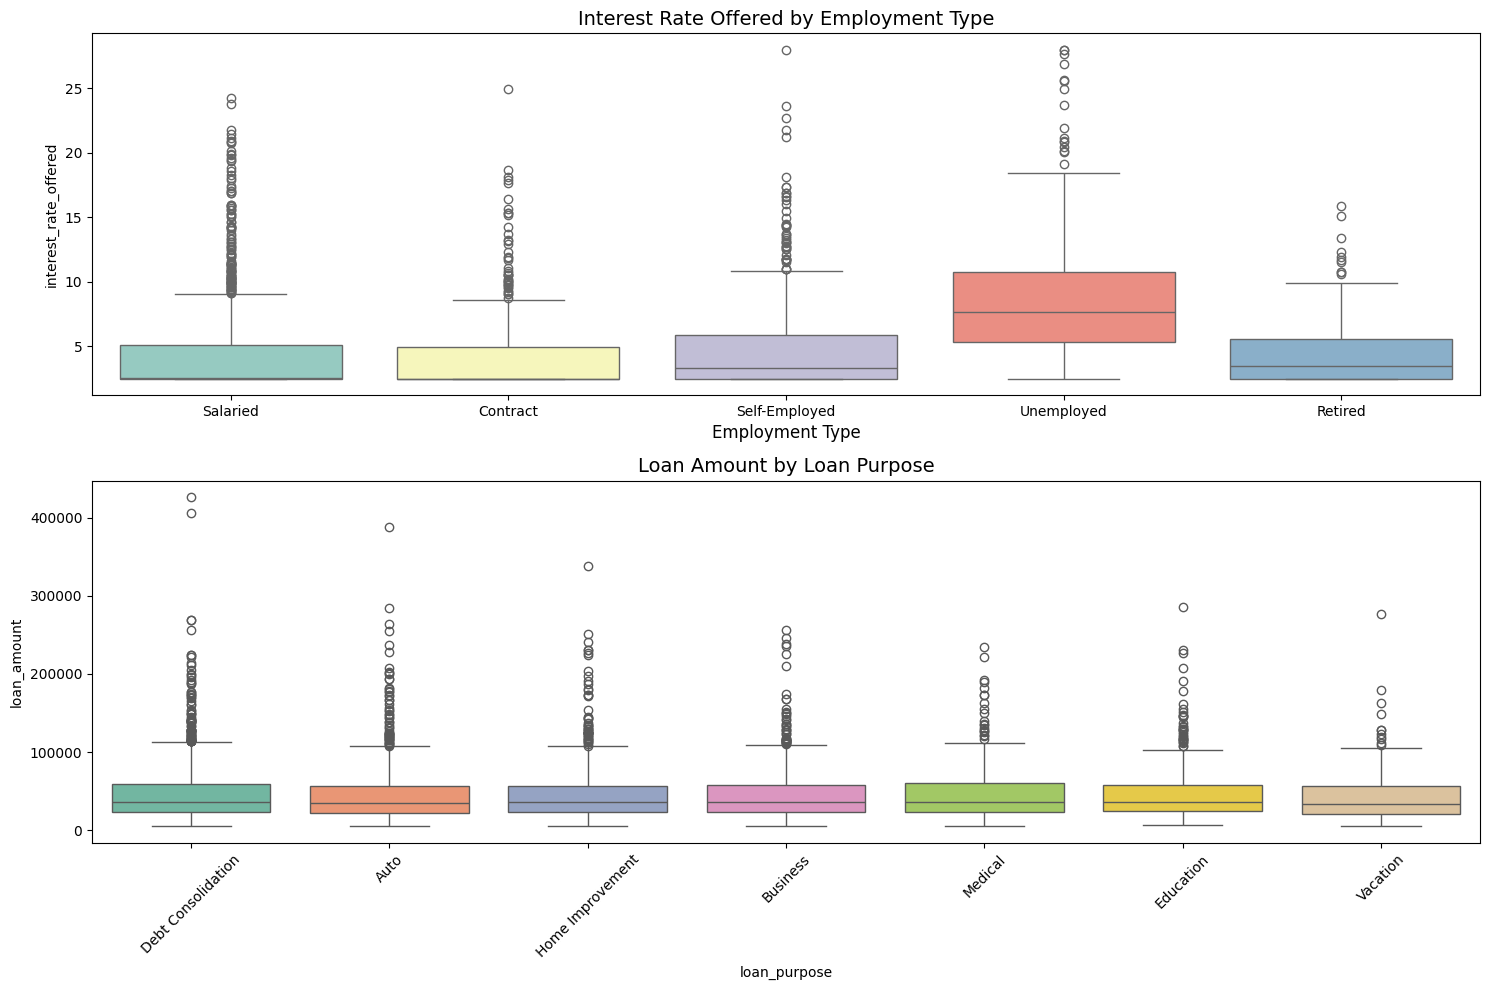

In [ ]:
fig, ax = plt.subplots(2,1,  figsize=(15,10))


sns.boxplot(data=df_copy, x='employment_type', y='interest_rate_offered', ax=ax[0], palette='Set3' ,hue='employment_type', legend=False)
ax[0].set_title("Interest Rate Offered by Employment Type", fontsize=14)
ax[0].set_xlabel("Employment Type", fontsize=12)


sns.boxplot(data=df_copy, x='loan_purpose', y='loan_amount', ax=ax[1], palette='Set2' ,hue='loan_purpose', legend=False)
ax[1].set_title("Loan Amount by Loan Purpose", fontsize=14)
ax[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('../reports/cat_figures/numxcat_boxplot.png', dpi=300)
plt.show()

# Cat vs Cat (Normalized Cross-tabulation)

Using a normalized cross-tabulation heatmap to analyze the behavioral distribution of Employment Type across different Loan Purposes.

## Findings
- **Salaried Dominance:** Across every single loan purpose, the **Salaried** group consistently represents over **50%** of the borrowers (ranging from 50% to 56%). This confirms the dataset is heavily skewed toward traditional earners regardless of the loan's use case.
- **Consistency:** The distribution of **Self-Employed** (~21%) and **Contract** (~14%) workers remains almost identical across all categories, suggesting that employment status doesn't drastically change the "why" behind the loan.
- **Niche Segments:**
    - **Retired** individuals have their highest relative representation in **Vacation** loans (9%), which is nearly double their representation in Debt Consolidation.
    - **Unemployed** borrowers are least likely to seek **Medical** loans (5%) but maintain a steady 7-8% presence in **Business** and **Auto** categories.

## Strategy
- **Address Class Imbalance:** Since Salaried individuals make up the majority of every row, I need to be careful about the model becoming biased. I will consider using **Class Weights** or **SMOTE** during the training phase.
- **Feature Importance:** Because the distribution is so uniform across all purposes, `loan_purpose` might have low predictive power for certain employment types. I’ll verify this later using Feature Importance or Mutual Information scores.

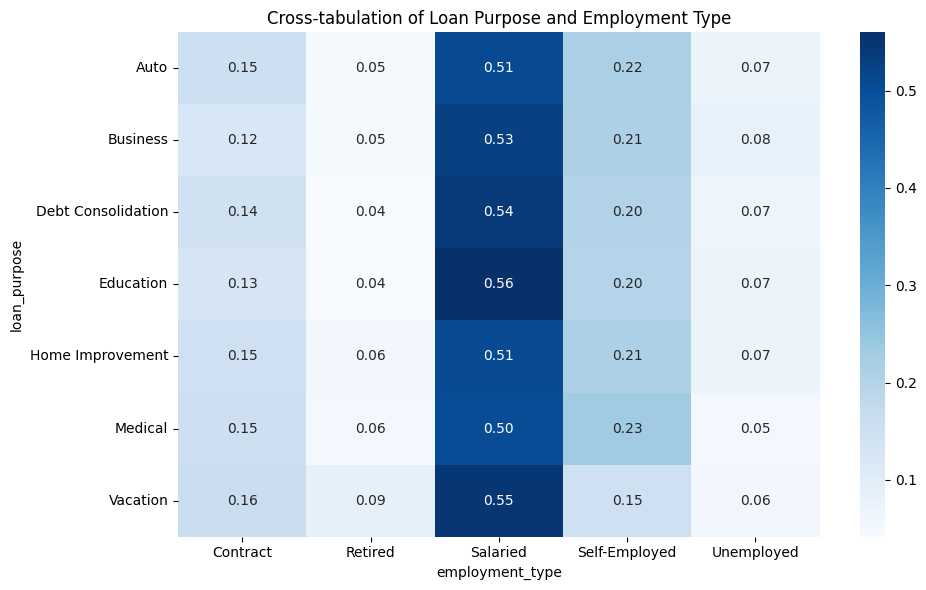

In [ ]:
# print(cat_cols)
plt.figure(figsize=(10,6))
cross_tab = pd.crosstab(df_copy['loan_purpose'], df_copy['employment_type'], normalize='index')
sns.heatmap(cross_tab, annot=True, fmt=".2f", cmap='Blues')
plt.title("Cross-tabulation of Loan Purpose and Employment Type")
plt.tight_layout()
plt.savefig('../reports/cat_figures/cross_tab_heatmap.png', dpi=300)
plt.show()

# FEATURE ENGINEERING AND CLEANING
refining data based on discoveries and stratgies: handle negatives is feasible, transformation, outliers, and impute

**Handling Negative Values**

- after checking there are 500 negative values on fed funds rate col and it is 10% of the total dataset. after thorough research the fed funds rate are not getting to zero.
- this might be a typo so the strategy is to get the absolute value of the columns' data


In [19]:
# print((df_copy[num_cols] < 0).sum())
# display(df_copy.shape)

df_copy['fed_funds_rate'] = df_copy['fed_funds_rate'].abs()
display((df_copy['fed_funds_rate'] < 0).sum())

np.int64(0)

**Imputation**

I previously found missing values in `annual_income` and `credit_score`. 
Since both features have skewness/outliers, the **median** is a much more robust imputation strategy than the mean.

In [34]:
# print(df_copy[['annual_income', 'credit_score']].isnull().sum())
df_copy['annual_income'] = df_copy['annual_income'].fillna(df_copy['annual_income'].median())
df_copy['credit_score'] = df_copy['credit_score'].fillna(df_copy['credit_score'].median())
print(df_copy[['annual_income', 'credit_score']].isnull().sum() )



annual_income    0
credit_score     0
dtype: int64


**Transformations**

Normalizing the heavily right-skewed columns we discovered earlier to stabilize variance and make them more normally distributed. We use `np.log1p()` (log(1+x)) to safely handle 0s.


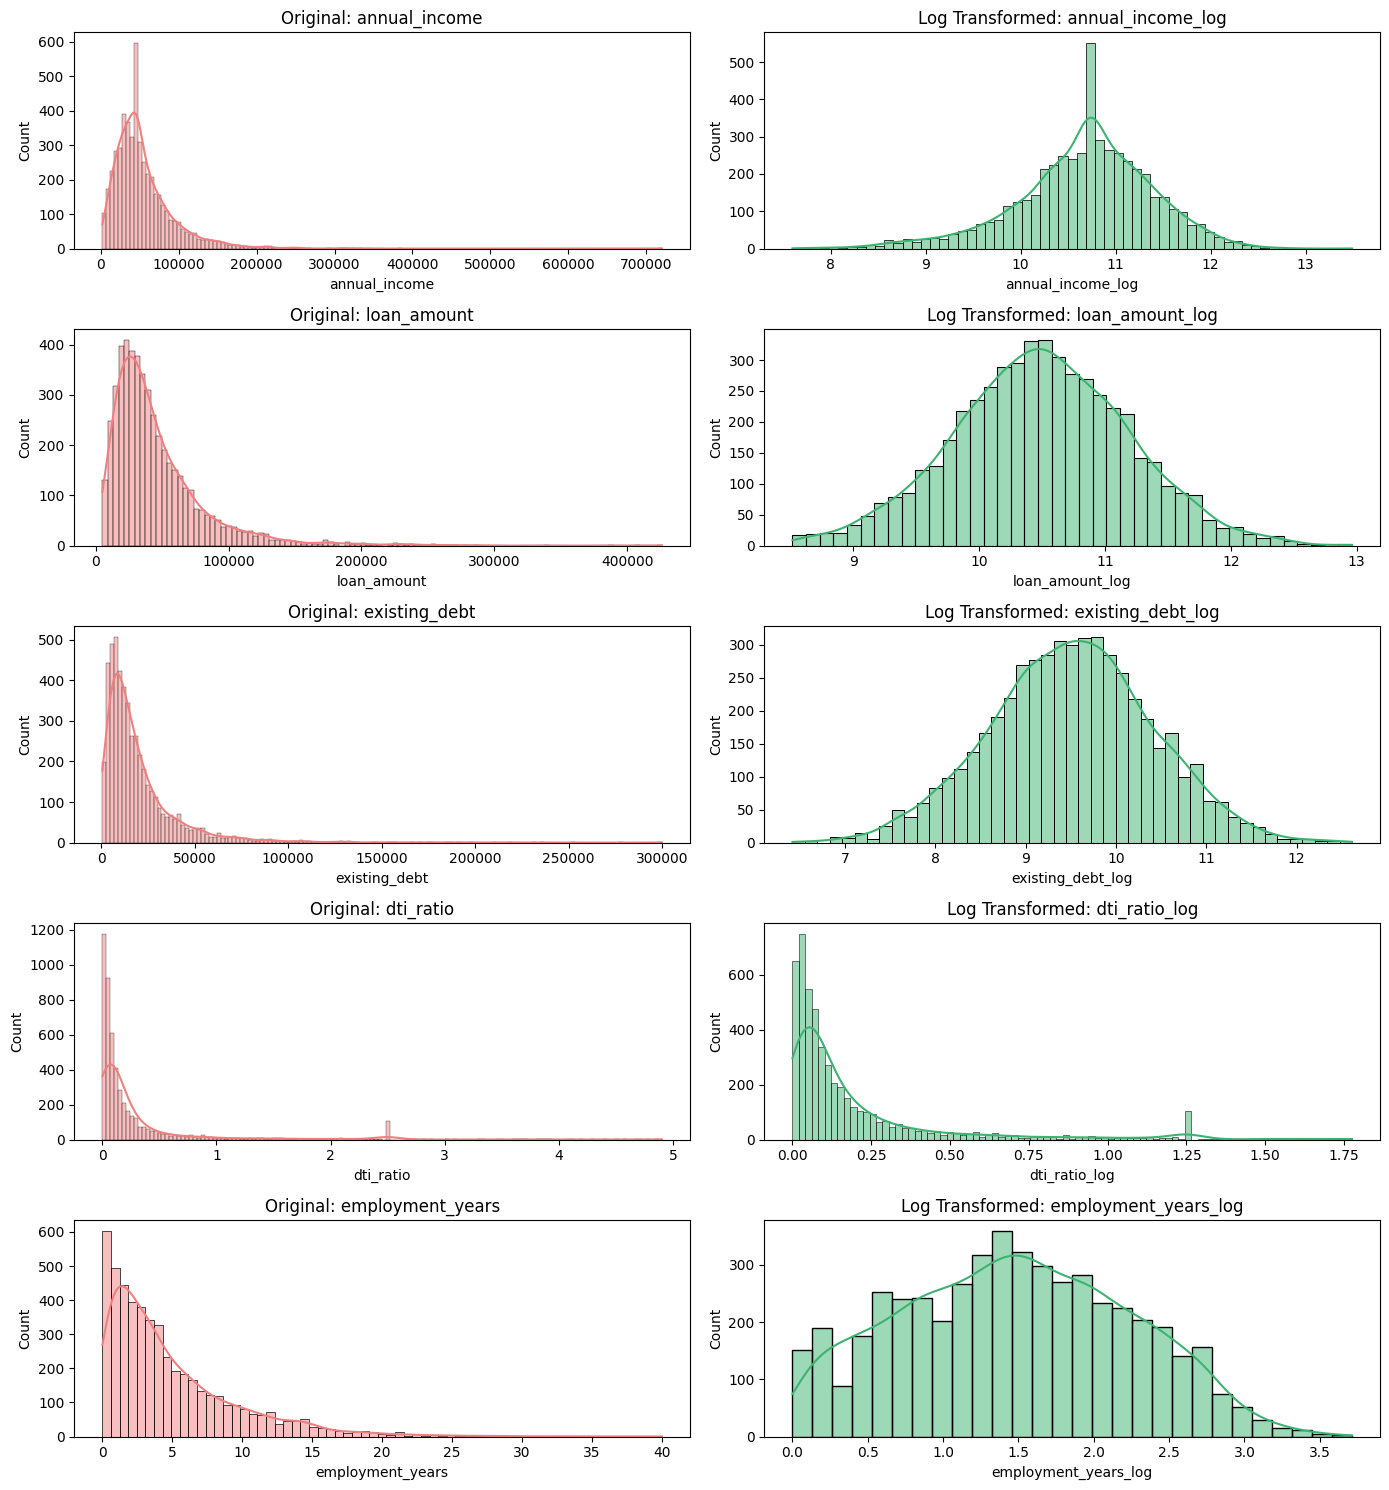

[annual_income_log]: -0.54
[loan_amount_log]: 0.01
[existing_debt_log]: -0.02
[dti_ratio_log]: 2.67
[employment_years_log]: 0.08


In [35]:
skewed_cols = ['annual_income', 'loan_amount', 'existing_debt', 'dti_ratio', 'employment_years']

fig, ax = plt.subplots(len(skewed_cols), 2, figsize=(14, 15))

for i, col in enumerate(skewed_cols):
    # Plot Original
    sns.histplot(df_copy[col], kde=True, ax=ax[i, 0], color='lightcoral')
    ax[i, 0].set_title(f'Original: {col}')
    
    # Apply Log Transformation
    df_copy[f'{col}_log'] = np.log1p(df_copy[col])
    
    # Plot Transformed
    sns.histplot(df_copy[f'{col}_log'], kde=True, ax=ax[i, 1], color='mediumseagreen')
    ax[i, 1].set_title(f'Log Transformed: {col}_log')

plt.tight_layout()
plt.savefig('../reports/num_figures/log_transformations.png', dpi=300)
plt.show()

for col in skewed_cols:
    skew_val = df_copy[f'{col}_log'].skew()
    print(f"[{col}_log]: {skew_val:.2f}")